## Population-Based Structural Health Monitoring (PBSHM)

### Objective
Detect whether a structure is damaged using measurement-like features and graph structure.

## Dataset Overview
- 50 structures
- Each has 4–8 storeys
- Structure Features:
  - Structure id (`structure_id`)
  - Number of Storeys (`n_storeys`)
  - Edges (`edges`)
  - Node Features (`n_features`)
  - Feature Names (`feature_names`)

- Node features:
  - Storey (`storey`)
  - height (`height_m`)
  - dominant modal frequency (`dominant_modal_frequency_Hz`)

- Available Structure Labels:
  - Structure id (`structure_id`)
  - Damaged (`damaged`)
  - Damage Storey (`damage_storey`)

In [91]:
"""
Imprting necessary libraries and setting up the environment 
for data analysis and visualization.
"""

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

plt.style.use('seaborn')


### Task1: Population Exploration (EDA)
Characterize the dataset and explain the variation across the population.

- Visualize the distribution of structure sizes and geometry
- Explore the starter population graph
- Inspect the provided measurement-like node features
- Propose which raw or derived features might be damage-sensitive


In [115]:
#-//--------- Data Loading and Preprocessing ---------//-

with open('structures_measurements.json') as f:
    structures = json.load(f)

labels = pd.read_csv('structure_labels.csv')

# Load population graph
edges = pd.read_csv("population_edges_geometry.csv")
weights = pd.read_csv("population_edge_weights_geometry.csv")

# Flatten node data
node_properties = []
for structure in structures:
    structure_id = structure['structure_id']
    n_storeys = structure['n_storeys']
    
    for node in structure['node_features']:
        node_propert = node.copy()
        node_propert['structure_id'] = structure_id
        node_propert['n_storeys'] = n_storeys
        node_properties.append(node_propert)

# Create DataFrame from node properties
nodes_df = pd.DataFrame(node_properties)

# Merge labels with node properties
nodes_df = nodes_df.merge(labels, on='structure_id')

#--//--------- Structure-Level Feature Extraction ---------//-
# Structure-level dataframe
structure_property = []
for structure in structures:
    structure_id = structure['structure_id']
    structure_property.append({
        'structure_id': structure_id,
        'n_storeys': structure['n_storeys'],
        'total_height': sum(n['height_m'] for n in structure['node_features']),
        'damaged': labels.loc[labels.structure_id == structure_id, 'damaged'].values[0]
    })

# Create DataFrame from structure properties
structure_df = pd.DataFrame(structure_property)


#nodes_df.head()
structure_df.head()

,structure_id,n_storeys,total_height,damaged
0,0,6,24.905,0
1,1,5,19.219,0
2,2,8,32.077,0
3,3,6,22.181,1
4,4,7,29.248,1


#### Distribution of Structure Sizes

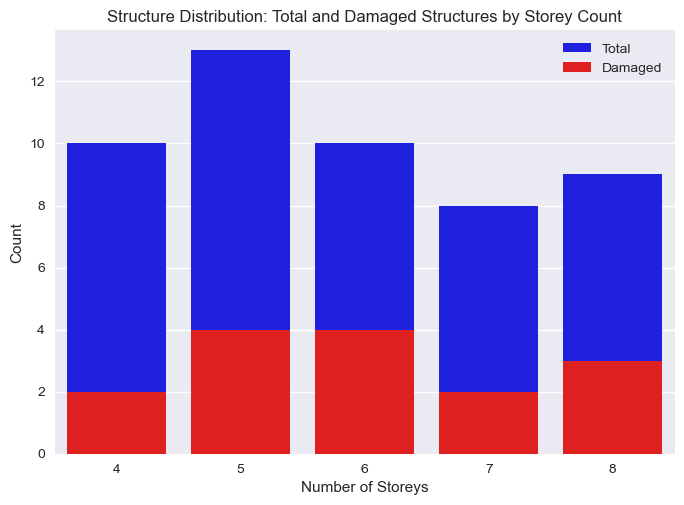

In [104]:
# Structure-level unique data
unique_structure_df = nodes_df[['structure_id', 'n_storeys', 'damaged']].drop_duplicates()

# Total structure count per group
total_counts = unique_structure_df['n_storeys']

# Damaged only
damaged_counts = unique_structure_df[unique_structure_df['damaged'] == 1]['n_storeys']

# Plot
sns.countplot(x=total_counts, color='blue', label='Total')
sns.countplot(x=damaged_counts, color='red', label='Damaged')

plt.title("Structure Distribution: Total and Damaged Structures by Storey Count")
plt.xlabel("Number of Storeys")
plt.ylabel("Count")
plt.legend()
plt.show()

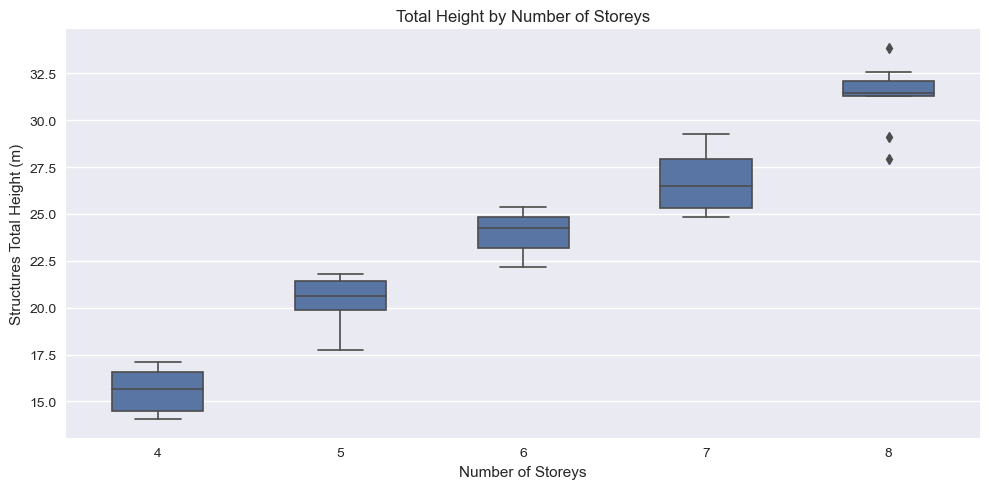

In [116]:
# Boxplot of Structure total height by number of storeys
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=structure_df,
    x='n_storeys',
    y='total_height',
    color='#4C72B0',   # clean, professional blue
    width=0.5,
    linewidth=1.2
)

plt.title("Total Height by Number of Storeys")
plt.xlabel("Number of Storeys")
plt.ylabel("Structures Total Height (m)")
plt.tight_layout()
plt.show()

- Hights are relatively well distributed across each story in a Structure group

#### Starter population graph

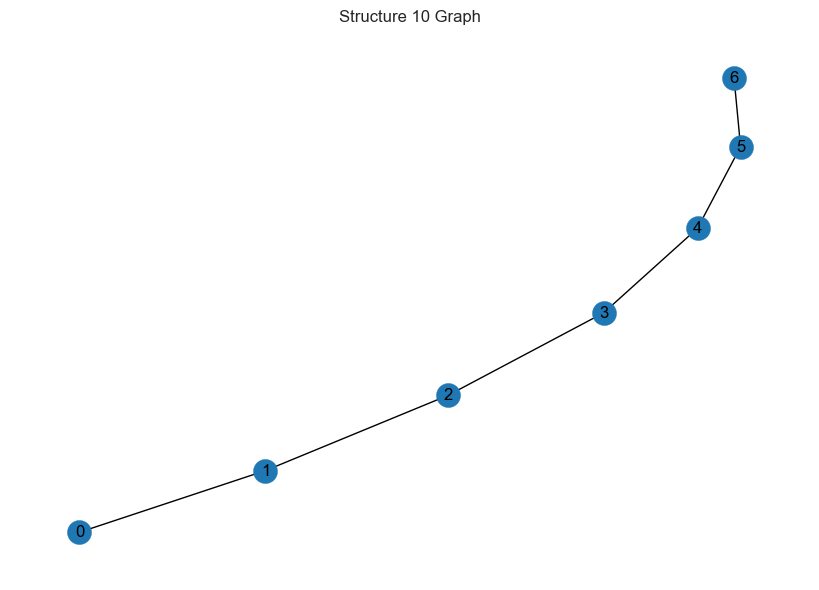

In [114]:
# Structure-level graph visualization
sample_structure = structures[10]

sample_structure_graph = nx.Graph()
sample_structure_graph.add_edges_from(sample_structure['edges'])

nx.draw(sample_structure_graph, with_labels=True)
plt.title(f"Structure {sample_structure['structure_id']} Graph")
plt.show()

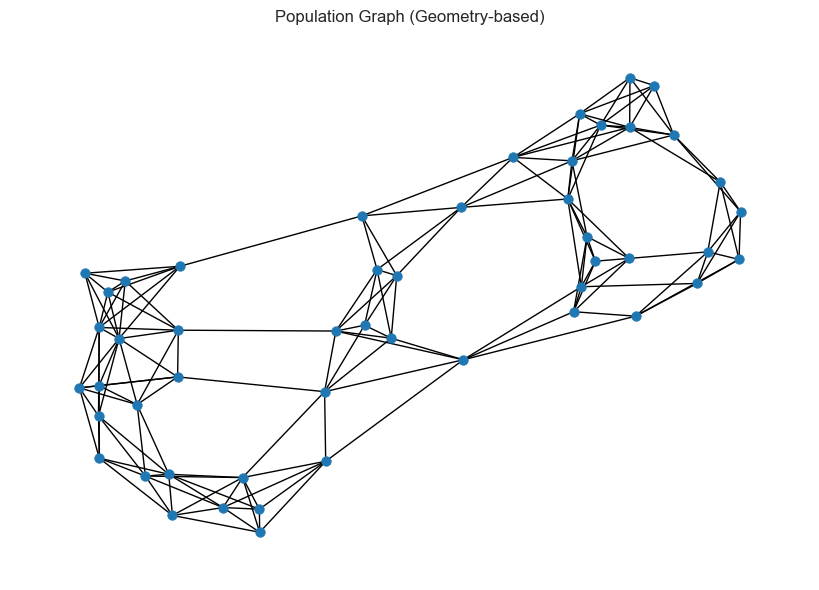

In [118]:
# Population graph visualization
structure_pop_graph = nx.from_pandas_edgelist(edges, 'source', 'target')

nx.draw(structure_pop_graph, node_size=50)
plt.title("Population Graph (Geometry-based)")

plt.show()

#### Inspection of Node features Measurement

